In [ ]:
# Student Pass/Fail Prediction


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


In [3]:
# Load dataset
data = pd.read_csv("student_pass_fail.csv")
data

,Study_Hours,Attendance_Percent,Assignment_Score,Internal_Marks,Pass
0,2.622427,65.909360,43.926795,69.866862,1
1,1.175277,60.900169,74.479357,40.910115,0
2,5.168967,92.246927,81.276175,39.273712,1
3,7.524405,65.108234,74.098350,78.454656,1
4,4.781832,71.911034,76.223593,86.454941,0
...,...,...,...,...,...
95,4.941633,93.962803,78.924044,96.254438,0
96,3.869832,66.018622,56.791407,75.594963,0
97,6.114607,64.935394,54.459577,91.733283,1
98,6.928231,51.386633,79.872940,80.342409,1


In [ ]:
#Q-1- Analyzing study patterns

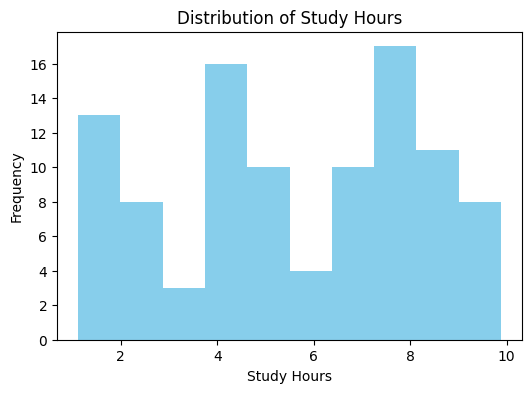

In [6]:
# 1.Study Hours distribution
plt.figure(figsize=(6,4))
plt.hist(data['Study_Hours'], bins=10, color='skyblue')
plt.title("Distribution of Study Hours")
plt.xlabel("Study Hours")
plt.ylabel("Frequency")
plt.show()

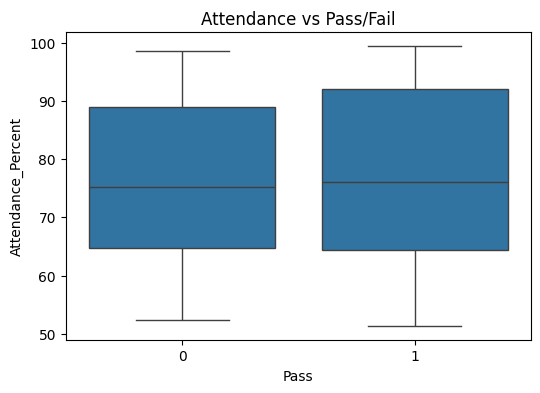

In [8]:
# 2.(Attendance vs Pass)
plt.figure(figsize=(6,4))
sns.boxplot(x='Pass', y='Attendance_Percent', data=data)
plt.title("Attendance vs Pass/Fail")
plt.show()


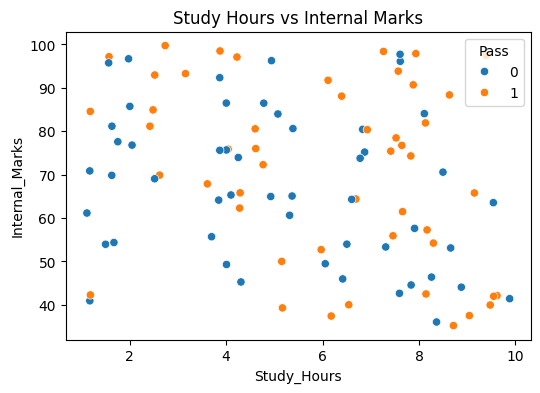

In [9]:
# 3.(Study Hours vs Internal Marks)
plt.figure(figsize=(6,4))
sns.scatterplot(x='Study_Hours', y='Internal_Marks', hue='Pass', data=data)
plt.title("Study Hours vs Internal Marks")
plt.show()

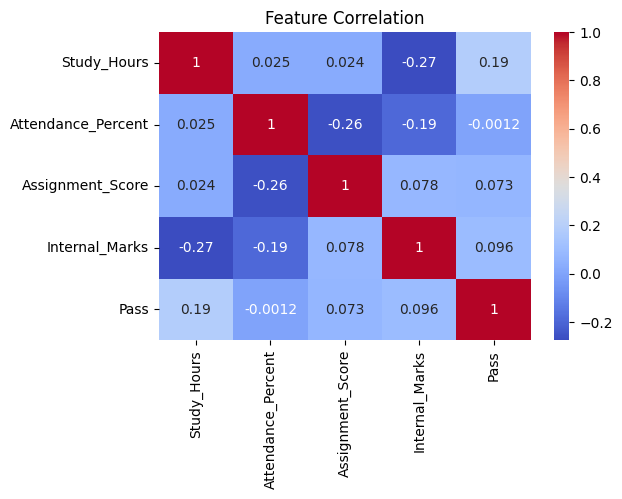

In [10]:
# 4 Correlation Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

In [18]:
#Q-2-Train classification model

In [19]:
# Features and target
X = data[['Study_Hours','Attendance_Percent','Assignment_Score','Internal_Marks']]
y = data['Pass']


In [13]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
# Train classification model
model = LogisticRegression()
model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [20]:
#Q-3-Predict pass/fail

In [21]:
# Predict
y_pred = model.predict(X_test)


In [22]:
# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.55


In [23]:
# Predict pass/fail for new student
sample = [[6, 85, 75, 70]]
prediction = model.predict(sample)

print("Prediction (1=Pass, 0=Fail):", prediction[0])

Prediction (1=Pass, 0=Fail): 1


C:\Users\Akrit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
